In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from datetime import datetime
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score


warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# Teams

In [2]:
home= "Genoa"
away= "Udinese"

In [3]:
df_home= pd.read_csv(f"../Data/{home}.csv")
df_home["Date"] = pd.to_datetime(df_home["Date"]) 
df_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
25,Genoa,Inter,2025-02-22,L,A,0,1,-1,0,0,...,0.8,0.9,-1.3,-1.3,-0.8,0.12,0,1.8,0.45,0.8
26,Genoa,Empoli,2025-03-02,D,H,1,1,0,1,0,...,0.3,0.3,0.7,0.7,0.7,0.07,0,0.2,0.19,-0.8
27,Genoa,Cagliari,2025-03-07,D,A,1,1,0,1,0,...,0.9,0.8,0.1,0.1,0.1,0.12,1,0.8,0.76,-0.2
28,Genoa,Lecce,2025-03-14,W,H,2,1,1,2,0,...,1.0,0.7,1.0,1.0,1.0,0.13,0,1.2,0.16,0.2
29,Genoa,Juventus,2025-03-29,L,A,0,1,-1,0,0,...,0.3,0.4,-0.4,-0.4,-0.3,0.04,0,1.6,0.26,0.6


In [4]:
df_vs_home= pd.read_csv(f"../Data/vs {home}.csv")
df_vs_home["Date"] = pd.to_datetime(df_vs_home["Date"]) 
df_vs_home.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
25,Inter,Genoa,2025-02-22,W,H,1,0,1,1,0,...,1.3,1.5,-0.5,-0.5,-0.3,0.09,0,1.1,0.53,1.1
26,Empoli,Genoa,2025-03-02,D,A,1,1,0,1,0,...,0.7,1.1,0.1,0.1,-0.7,0.13,1,0.4,0.39,-0.6
27,Cagliari,Genoa,2025-03-07,D,H,1,1,0,1,0,...,0.6,0.5,0.3,0.3,0.4,0.08,1,0.5,0.27,-0.5
28,Lecce,Genoa,2025-03-14,L,A,1,2,-1,0,1,...,0.4,0.3,-0.2,-0.6,-0.4,0.04,1,1.3,0.64,-0.7
29,Juventus,Genoa,2025-03-29,W,H,1,0,1,1,0,...,0.9,0.8,0.1,0.1,0.1,0.10,0,0.2,0.07,0.2


In [5]:
df_away= pd.read_csv(f"../Data/{away}.csv")
df_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
25,Udinese,Lecce,2025-02-21,W,A,1,0,1,0,1,...,0.7,0.8,-0.6,-0.8,-0.7,0.07,0,0.5,0.52,0.5
26,Udinese,Parma,2025-03-01,W,H,1,0,1,0,1,...,1.1,0.7,-1.3,-1.5,-1.1,0.08,1,0.8,0.26,0.8
27,Udinese,Lazio,2025-03-10,D,A,1,1,0,1,0,...,0.9,0.2,-0.2,-0.2,0.1,0.10,1,1.3,0.39,0.3
28,Udinese,Hellas Verona,2025-03-15,L,H,0,1,-1,0,0,...,0.4,0.7,-0.5,-0.5,-0.4,0.05,1,0.6,0.29,-0.4
29,Udinese,Inter,2025-03-30,L,A,1,2,-1,1,0,...,0.5,0.3,0.3,0.3,-0.5,0.06,0,1.4,0.69,-0.6


In [6]:
df_vs_away= pd.read_csv(f"../Data/vs {away}.csv")
df_vs_away["Date"] = pd.to_datetime(df_away["Date"]) 
df_vs_away.tail()

,Team,Opp,Date,Result,H/A,GF,GA,GD,G-PK,PK,...,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,PSxG,PSxG/SoT,PSxG+/-
25,Lecce,Udinese,2025-02-21,L,H,0,1,-1,0,0,...,0.3,0.5,-0.4,-0.4,-0.3,0.04,0,2.0,0.20,1.0
26,Parma,Udinese,2025-03-01,L,A,0,1,-1,0,0,...,0.8,0.5,-0.8,-0.8,-0.8,0.10,0,1.2,0.06,0.2
27,Lazio,Udinese,2025-03-10,D,H,1,1,0,1,0,...,1.2,0.8,-0.2,-0.2,-0.2,0.12,0,1.7,0.47,0.7
28,Hellas Verona,Udinese,2025-03-15,W,A,1,0,1,1,0,...,0.3,0.3,0.6,0.6,-0.3,0.05,1,0.4,0.13,0.4
29,Inter,Udinese,2025-03-30,W,H,2,1,1,2,0,...,1.4,1.4,0.3,0.3,0.6,0.14,0,1.7,0.42,0.7


In [7]:
print(list(df_away.columns))

['Team', 'Opp', 'Date', 'Result', 'H/A', 'GF', 'GA', 'GD', 'G-PK', 'PK', 'PKatt', 'PKm', 'Poss', 'Att (GK)', 'Thr', 'Pa Launch%', 'Pa AvgLen', 'Won', 'Lost', 'Won%', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 'PrgC', 'Last3rd Car', 'OppCr', 'Stp', 'Stp%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'GK Att', 'Launch%', 'AvgLen', 'Sh', 'G/Sh', 'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'PKcon', 'OG', 'Recov', '#OPA', 'AvgDist', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'PKdef', 'PKA', 'PKms', 'Missed PK%', 'PKAg', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassL

# Desc

# Features

## Offense

In [8]:
offense= ['G-PK', 'PK', 'PKm', 'Poss', 'PKatt', 'Att To', 'Succ', 'Succ%', 'Tkld', 'Tkld%', 'Carries', 'TotDist', 'PrgDist', 
          'PrgC', 'Last3rd Car', 'GCA', 'PassLive Gc', 'PassDead Gc', 'TO Gc', 'Sh-Gc', 'Fld Gc', 'Def-Gc', 'Sh', 'G/Sh', 
          'G/SoT', 'SoT', 'SoT%', 'Dist', 'FK', 'Off', 'PKwon', 'Cmp', 'Pas Att', 'Cmp%', 'KP', 'Last3rd PA', 'PPA', 'CrsPA', 
          'PrgP', 'TotDist Pas', 'PrgDist Pas', 'Cmp 5-15', 'Att 5-15', 'Cmp% 5-15', 'Cmp 15-30', 'Att 15-30', 'Cmp% 15-30', 
          'Cmp 30+', 'Att 30+', 'Cmp% 30+', 'Live Pas', 'Dead', 'Pas FK', 'TB', 'Sw', 'Crs', 'TI', 'CK', 'In', 'Out', 'Str', 
          'Ps Off', 'PTo', 'Rec', 'Last3rd Rec', 'CPA', 'Mis', 'Dis', 'SCA', 'PassLive Sc', 'PassDead Sc', 'TO Sc', 'Sh-Sh', 
          'Fld Sc', 'Def-Sc', 'Touches', 'Def Pen', 'Tch Def 3rd', 'Tch Mid 3rd', 'Tch Att 3rd', 'Att Pen', 'Live Tch', 'xG', 
          'npxG', 'xGD', 'npxGD', 'xAG', 'xA', 'G-xG', 'np:G-xG', 'A-xAG', 'npxG/Sh', 'FKAtt', 'GF']

In [9]:
df_home_off= df_home[offense]
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
25,0,0,0,38,0,9,6,66.7,2,22.2,...,-0.2,-0.2,0.8,0.9,-1.3,-1.3,-0.8,0.12,0,0
26,1,0,0,60,0,18,6,33.3,11,61.1,...,-0.6,-0.6,0.3,0.3,0.7,0.7,0.7,0.07,0,1
27,1,0,0,53,0,8,1,12.5,7,87.5,...,0.3,0.3,0.9,0.8,0.1,0.1,0.1,0.12,1,1
28,2,0,0,44,0,18,7,38.9,8,44.4,...,-0.2,0.5,1.0,0.7,1.0,1.0,1.0,0.13,0,2
29,0,0,0,51,0,18,5,27.8,12,66.7,...,-0.6,-0.6,0.3,0.4,-0.4,-0.4,-0.3,0.04,0,0


In [10]:
df_vs_home_off= df_vs_home[offense]
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
25,1,0,0,62,0,13,5,38.5,5,38.5,...,0.2,0.2,1.3,1.5,-0.5,-0.5,-0.3,0.09,0,1
26,1,0,0,40,0,10,5,50.0,3,30.0,...,0.6,0.6,0.7,1.1,0.1,0.1,-0.7,0.13,1,1
27,1,0,0,47,0,10,5,50.0,4,40.0,...,-0.3,-0.3,0.6,0.5,0.3,0.3,0.4,0.08,1,1
28,0,1,0,56,1,12,9,75.0,2,16.7,...,0.2,-0.5,0.4,0.3,-0.2,-0.6,-0.4,0.04,1,1
29,1,0,0,49,0,24,12,50.0,10,41.7,...,0.6,0.6,0.9,0.8,0.1,0.1,0.1,0.10,0,1


In [11]:
df_away_off= df_away[offense]
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
25,0,1,0,55,1,30,13,43.3,14,46.7,...,1.2,0.4,0.7,0.8,-0.6,-0.8,-0.7,0.07,0,1
26,0,1,0,43,1,12,6,50.0,4,33.3,...,1.4,0.7,1.1,0.7,-1.3,-1.5,-1.1,0.08,1,1
27,1,0,0,51,0,18,9,50.0,8,44.4,...,0.1,0.1,0.9,0.2,-0.2,-0.2,0.1,0.10,1,1
28,0,0,0,64,0,19,8,42.1,9,47.4,...,0.2,0.2,0.4,0.7,-0.5,-0.5,-0.4,0.05,1,0
29,1,0,0,40,0,20,10,50.0,7,35.0,...,-1.0,-1.0,0.5,0.3,0.3,0.3,-0.5,0.06,0,1


In [12]:
df_vs_away_off= df_vs_away[offense]
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,xGD,npxGD,xAG,xA,G-xG,np:G-xG,A-xAG,npxG/Sh,FKAtt,GF
25,0,0,0,45,0,14,6,42.9,7,50.0,...,-1.2,-0.4,0.3,0.5,-0.4,-0.4,-0.3,0.04,0,0
26,0,0,0,57,0,13,4,30.8,8,61.5,...,-1.4,-0.7,0.8,0.5,-0.8,-0.8,-0.8,0.10,0,0
27,1,0,0,49,0,15,6,40.0,6,40.0,...,-0.1,-0.1,1.2,0.8,-0.2,-0.2,-0.2,0.12,0,1
28,1,0,0,36,0,14,2,14.3,8,57.1,...,-0.2,-0.2,0.3,0.3,0.6,0.6,-0.3,0.05,1,1
29,2,0,0,60,0,11,8,72.7,2,18.2,...,1.0,1.0,1.4,1.4,0.3,0.3,0.6,0.14,0,2


## Defence

In [13]:
defence= ['OppCr', 'Stp', 'Stp%', 'PKcon', '#OPA', 'AvgDist', 'PKsv', 'PK Save%', 'FK Ag', 'CKG', 'OGK', 'SoTA', 'Saves', 
          'Save%', 'Tkl', 'TklW', 'Tkl Def 3rd', 'Tkl Mid 3rd', 'Tkl Att 3rd', 'Tkl.2', 'Tkl Att', 'Tkl%', 'Lost Tkl', 
          'Ints', 'BlcSh', 'Pass', 'Int', 'Tkl+Int', 'Clr', 'Err',  'PSxG', 'PSxG/SoT', 'PSxG+/-', 'GA']

In [14]:
df_home_def= df_home[defence]
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
25,17,2,11.8,0,0,6.3,0,NaN,0,1,...,8,11,8,21,42,0,1.8,0.45,0.8,1
26,16,1,6.3,0,3,19.0,0,NaN,0,1,...,2,9,7,22,47,0,0.2,0.19,-0.8,1
27,10,1,10.0,0,1,13.2,0,NaN,0,0,...,2,11,6,20,26,0,0.8,0.76,-0.2,1
28,12,2,16.7,1,0,10.0,0,0.0,0,0,...,7,9,10,23,22,0,1.2,0.16,0.2,1
29,11,1,9.1,0,1,12.0,0,NaN,0,0,...,0,8,8,32,21,2,1.6,0.26,0.6,1


In [15]:
df_vs_home_def= df_vs_home[defence]
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
25,20,1,5.0,0,1,23.5,0,NaN,0,0,...,5,9,7,15,28,1,1.1,0.53,1.1,0
26,7,1,14.3,0,1,11.5,0,NaN,0,1,...,0,8,10,30,31,1,0.4,0.39,-0.6,1
27,15,0,0.0,0,1,14.0,0,NaN,0,0,...,1,10,10,20,24,0,0.5,0.27,-0.5,1
28,5,0,0.0,0,0,8.3,0,NaN,0,0,...,1,9,5,25,20,0,1.3,0.64,-0.7,2
29,11,0,0.0,0,0,9.0,0,NaN,0,0,...,1,13,6,29,19,1,0.2,0.07,0.2,0


In [16]:
df_away_def= df_away[defence]
df_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,25,2,8.0,1,0,5.5,0,0.0,0,0,...,8,9,10,25,26,0,2.2,0.22,1.2,1
1,32,0,0.0,0,2,20.3,0,NaN,0,0,...,3,4,9,27,40,0,1.7,0.45,0.7,1
2,17,0,0.0,1,0,8.5,0,NaN,0,0,...,6,16,11,33,27,1,0.3,0.08,0.3,0
3,3,0,0.0,0,0,10.5,0,NaN,0,1,...,1,2,15,29,12,0,1.1,0.37,-0.9,2
4,10,0,0.0,1,1,21.0,0,0.0,0,0,...,4,3,11,24,17,1,2.6,0.21,-0.4,3


In [17]:
df_vs_away_def= df_vs_away[defence]
df_vs_away_def.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,BlcSh,Pass,Int,Tkl+Int,Clr,Err,PSxG,PSxG/SoT,PSxG+/-,GA
0,12,0,0.0,1,2,23.5,1,100.0,0,1,...,2,6,3,19,17,0,0.9,0.00,-0.1,1
1,9,0,0.0,0,0,6.0,0,NaN,0,0,...,1,4,6,17,9,0,1.6,0.54,-0.4,2
2,11,0,0.0,0,0,18.0,0,NaN,0,0,...,3,7,11,37,21,0,0.6,0.31,-0.4,1
3,21,2,9.5,0,2,16.3,0,NaN,0,0,...,3,4,4,12,24,1,2.5,0.43,-0.5,3
4,5,0,0.0,0,0,8.3,0,NaN,0,0,...,3,4,7,17,11,1,0.9,0.44,0.9,0


## Combined

In [18]:
combined= ['Won', 'Lost', 'Won%', 'CrdY', 'CrdR', '2CrdY', 'Fls', 'Fld', 'Recov']

In [19]:
df_home_cmb= df_home[combined]
df_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
25,17,35,32.7,2,0,0,14,6,49
26,23,30,43.4,1,0,0,12,17,42
27,29,23,55.8,2,0,0,15,16,48
28,16,28,36.4,3,0,0,12,10,56
29,16,24,40.0,2,0,0,11,12,40


In [20]:
df_vs_home_cmb= df_vs_home[combined]
df_vs_home_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
25,35,17,67.3,0,0,0,7,14,47
26,30,23,56.6,3,0,0,18,12,38
27,23,29,44.2,2,0,0,16,15,47
28,28,16,63.6,2,0,0,10,11,47
29,24,16,60.0,2,0,0,13,11,38


In [21]:
df_away_cmb= df_away[combined]
df_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
25,15,18,45.5,3,0,0,11,14,46
26,12,8,60.0,1,0,0,15,6,46
27,8,13,38.1,4,0,0,11,7,33
28,23,20,53.5,5,0,0,21,14,49
29,13,14,48.1,0,0,0,14,7,35


In [22]:
df_vs_away_cmb= df_vs_away[combined]
df_vs_away_cmb.tail()

,Won,Lost,Won%,CrdY,CrdR,2CrdY,Fls,Fld,Recov
25,18,15,54.5,1,0,0,15,10,43
26,8,12,40.0,1,0,0,7,15,30
27,13,8,61.9,2,0,0,9,10,32
28,20,23,46.5,2,0,0,16,20,37
29,14,13,51.9,2,0,0,8,12,35


## By Team

In [23]:
def create_lagged_features(df, target_cols, window= 4):
    """
    Creates lagged and rolling window features for a given dataset.
    
    Parameters:
    df (pd.DataFrame): The input dataframe containing game-by-game data.
    team_col (str): The column name representing the team.
    date_col (str): The column name representing the game date.
    target_cols (list): List of columns to create lagged and rolling features for.
    opponent_col (str, optional): Column representing the opponent team (if applicable).
    lags (list): List of lag periods to include.
    rolling_windows (list): List of rolling window sizes for moving averages and std dev.
    
    Returns:
    pd.DataFrame: Dataframe with additional lagged and rolling features.
    """
    df = df.copy()
    
    
    # Create lagged features for the given columns
    #for col in target_cols:
     #   for lag in range(1, window+1):
      #      df[f'{col}_lag_{lag}'] = df[col].shift(lag)
    
    # Create rolling window features (mean & std)
    for col in target_cols:
        df[f'{col}_rolling_avg_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).mean()
        df[f'{col}_rolling_std_{window}'] = df[col].shift(1).rolling(window, min_periods= 1).std()
    
    # Fill NA values (after shifting to avoid data leakage)
    df = df.fillna(0)
    
    return df


In [24]:
df_home_off= create_lagged_features(df_home_off, offense)
df_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
25,0,0,0,38,0,9,6,66.7,2,22.2,...,1.750000e-01,0.573730,0.325,0.573730,0.0900,0.028284,0.25,0.5,1.5,0.577350
26,1,0,0,60,0,18,6,33.3,11,61.1,...,-1.750000e-01,0.942956,0.025,0.793200,0.0925,0.030957,0.25,0.5,1.0,0.816497
27,1,0,0,53,0,8,1,12.5,7,87.5,...,1.500000e-01,0.971253,0.325,0.754431,0.0875,0.033040,0.00,0.0,1.0,0.816497
28,2,0,0,44,0,18,7,38.9,8,44.4,...,-2.081668e-17,0.901850,0.150,0.685565,0.1050,0.023805,0.25,0.5,1.0,0.816497
29,0,0,0,51,0,18,5,27.8,12,66.7,...,1.250000e-01,1.021029,0.250,0.793725,0.1100,0.027080,0.25,0.5,1.0,0.816497


In [25]:
df_vs_home_off= create_lagged_features(df_vs_home_off, offense)
df_vs_home_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
25,1,0,0,62,0,13,5,38.5,5,38.5,...,-0.075,0.925113,0.025,0.865544,0.0825,0.015000,0.25,0.50000,0.75,0.957427
26,1,0,0,40,0,10,5,50.0,3,30.0,...,-0.100,0.938083,0.050,0.850490,0.0825,0.015000,0.25,0.50000,1.00,0.816497
27,1,0,0,47,0,10,5,50.0,4,40.0,...,-0.400,0.346410,-0.450,0.238048,0.0900,0.028284,0.50,0.57735,0.75,0.500000
28,0,1,0,56,1,12,9,75.0,2,16.7,...,-0.150,0.412311,-0.200,0.454606,0.0925,0.026300,0.75,0.50000,0.75,0.500000
29,1,0,0,49,0,24,12,50.0,10,41.7,...,-0.175,0.442531,-0.250,0.465475,0.0850,0.036968,0.75,0.50000,1.00,0.000000


In [26]:
df_away_def= create_lagged_features(df_away_def, defence)
df_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
25,19,1,5.3,0,1,22.5,0,0.0,0,0,...,0.25,0.5,1.550,1.236932,0.255,0.064550,0.300,1.101514,1.25,0.957427
26,11,1,9.1,0,0,15.0,0,0.0,0,0,...,0.00,0.0,0.825,0.236291,0.335,0.134288,0.075,0.869387,0.75,0.957427
27,13,0,0.0,0,0,15.0,0,0.0,0,1,...,0.00,0.0,0.775,0.206155,0.315,0.139164,0.525,0.525198,0.25,0.500000
28,11,0,0.0,0,0,12.3,0,0.0,1,0,...,0.25,0.5,0.900,0.336650,0.360,0.121929,0.650,0.310913,0.25,0.500000
29,5,0,0.0,0,2,19.3,0,0.0,0,0,...,0.25,0.5,0.800,0.355903,0.365,0.117331,0.300,0.509902,0.50,0.577350


In [27]:
df_vs_away_def= create_lagged_features(df_vs_away_def, defence)
df_vs_away_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
25,16,1,6.3,1,0,8.6,0,0.0,0,0,...,0.50,0.57735,1.600,1.051982,0.3150,0.157162,-0.400,0.200000,2.00,1.154701
26,21,2,9.5,1,3,19.6,0,0.0,0,0,...,0.25,0.50000,1.875,0.946485,0.2925,0.168003,-0.125,0.750000,2.00,1.154701
27,16,1,6.3,0,1,20.3,0,0.0,0,0,...,0.25,0.50000,1.550,0.881287,0.1825,0.125532,0.050,0.714143,1.50,1.000000
28,8,1,12.5,0,0,4.0,0,0.0,0,0,...,0.25,0.50000,1.850,0.544671,0.2700,0.178326,0.350,0.655744,1.50,1.000000
29,15,0,0.0,0,2,17.0,0,0.0,0,0,...,0.25,0.50000,1.325,0.699405,0.2150,0.179351,0.575,0.350000,0.75,0.500000


In [28]:
df_away_off= create_lagged_features(df_away_off, offense)
df_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
25,0,1,0,55,1,30,13,43.3,14,46.7,...,0.875,1.043631,0.600,0.673300,0.0925,0.037749,0.00,0.00000,2.00,1.154701
26,0,1,0,43,1,12,6,50.0,4,33.3,...,0.625,1.337597,0.325,0.950000,0.0900,0.039158,0.00,0.00000,2.00,1.154701
27,1,0,0,51,0,18,9,50.0,8,44.4,...,-0.350,0.988264,-0.350,0.655744,0.0975,0.030957,0.25,0.50000,1.50,1.000000
28,0,0,0,64,0,19,8,42.1,9,47.4,...,-0.450,0.932738,-0.375,0.629153,0.0975,0.030957,0.50,0.57735,1.50,1.000000
29,1,0,0,40,0,20,10,50.0,7,35.0,...,-0.750,0.556776,-0.525,0.505800,0.0750,0.020817,0.75,0.50000,0.75,0.500000


In [29]:
df_vs_away_off= create_lagged_features(df_vs_away_off, offense)
df_vs_away_off.tail()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,np:G-xG_rolling_avg_4,np:G-xG_rolling_std_4,A-xAG_rolling_avg_4,A-xAG_rolling_std_4,npxG/Sh_rolling_avg_4,npxG/Sh_rolling_std_4,FKAtt_rolling_avg_4,FKAtt_rolling_std_4,GF_rolling_avg_4,GF_rolling_std_4
25,0,0,0,45,0,14,6,42.9,7,50.0,...,-0.625,1.252664,-0.550,0.793725,0.0950,0.033166,0.75,0.50000,1.25,0.957427
26,0,0,0,57,0,13,4,30.8,8,61.5,...,-0.450,1.212436,-0.475,0.801561,0.0825,0.043493,0.75,0.50000,0.75,0.957427
27,1,0,0,49,0,15,6,40.0,6,40.0,...,-0.850,0.881287,-0.600,0.804156,0.0850,0.044347,0.50,0.57735,0.25,0.500000
28,1,0,0,36,0,14,2,14.3,8,57.1,...,-0.875,0.853913,-0.725,0.639661,0.1000,0.043205,0.25,0.50000,0.25,0.500000
29,2,0,0,60,0,11,8,72.7,2,18.2,...,-0.200,0.588784,-0.400,0.270801,0.0775,0.038622,0.25,0.50000,0.50,0.577350


In [30]:
df_home_def= create_lagged_features(df_home_def, defence)
df_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
25,17,2,11.8,0,0,6.3,0,0.0,0,1,...,0.0,0.0,0.500,0.509902,0.1300,0.090554,8.326673e-17,0.571548,0.75,0.957427
26,16,1,6.3,0,3,19.0,0,0.0,0,1,...,0.0,0.0,0.950,0.685565,0.2350,0.155885,2.000000e-01,0.697615,1.00,0.816497
27,10,1,10.0,0,1,13.2,0,0.0,0,0,...,0.0,0.0,0.700,0.743864,0.2225,0.157348,2.000000e-01,0.697615,0.75,0.500000
28,12,2,16.7,1,0,10.0,0,0.0,0,0,...,0.0,0.0,0.775,0.732006,0.3725,0.299597,2.500000e-02,0.684957,0.75,0.500000
29,11,1,9.1,0,1,12.0,0,0.0,0,0,...,0.0,0.0,1.000,0.673300,0.3900,0.278927,9.714451e-17,0.673300,1.00,0.000000


In [31]:
df_vs_home_def= create_lagged_features(df_vs_home_def, defence)
df_vs_home_def.tail()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,Err_rolling_avg_4,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4
25,20,1,5.0,0,1,23.5,0,0.0,0,0,...,0.25,0.50000,1.700,1.174734,0.3600,0.108628,0.200,0.761577,1.5,0.577350
26,7,1,14.3,0,1,11.5,0,0.0,0,1,...,0.50,0.57735,1.175,0.618466,0.3900,0.139284,0.175,0.718215,1.0,0.816497
27,15,0,0.0,0,1,14.0,0,0.0,0,0,...,0.75,0.50000,0.950,0.714143,0.3775,0.135493,-0.050,0.802081,1.0,0.816497
28,5,0,0.0,0,0,8.3,0,0.0,0,0,...,0.50,0.57735,0.975,0.689807,0.3950,0.106301,-0.025,0.780491,1.0,0.816497
29,11,0,0.0,0,0,9.0,0,0.0,0,0,...,0.50,0.57735,0.825,0.442531,0.4575,0.161529,-0.175,0.853913,1.0,0.816497


In [32]:
df_home_cmb.rename(columns= {col: f"h_{col}" for col in df_home_cmb.columns}, inplace= True)
df_home_cmb= create_lagged_features(df_home_cmb, df_home_cmb.columns)
df_home_cmb.tail()

,h_Won,h_Lost,h_Won%,h_CrdY,h_CrdR,h_2CrdY,h_Fls,h_Fld,h_Recov,h_Won_rolling_avg_4,...,h_CrdR_rolling_avg_4,h_CrdR_rolling_std_4,h_2CrdY_rolling_avg_4,h_2CrdY_rolling_std_4,h_Fls_rolling_avg_4,h_Fls_rolling_std_4,h_Fld_rolling_avg_4,h_Fld_rolling_std_4,h_Recov_rolling_avg_4,h_Recov_rolling_std_4
25,17,35,32.7,2,0,0,14,6,49,20.50,...,0.0,0.0,0.0,0.0,12.75,1.892969,14.50,3.415650,42.50,5.802298
26,23,30,43.4,1,0,0,12,17,42,19.25,...,0.0,0.0,0.0,0.0,13.00,2.000000,11.25,3.862210,46.25,2.217356
27,29,23,55.8,2,0,0,15,16,48,22.75,...,0.0,0.0,0.0,0.0,12.50,1.914854,12.25,4.856267,45.50,3.109126
28,16,28,36.4,3,0,0,12,10,56,25.00,...,0.0,0.0,0.0,0.0,13.75,1.258306,13.50,5.066228,46.50,3.109126
29,16,24,40.0,2,0,0,11,12,40,21.25,...,0.0,0.0,0.0,0.0,13.25,1.500000,12.25,5.188127,48.75,5.737305


In [33]:
df_vs_home_cmb.rename(columns= {col: f"vh_{col}" for col in df_vs_home_cmb.columns}, inplace= True)
df_vs_home_cmb= create_lagged_features(df_vs_home_cmb, df_vs_home_cmb.columns)
df_vs_home_cmb.tail()

,vh_Won,vh_Lost,vh_Won%,vh_CrdY,vh_CrdR,vh_2CrdY,vh_Fls,vh_Fld,vh_Recov,vh_Won_rolling_avg_4,...,vh_CrdR_rolling_avg_4,vh_CrdR_rolling_std_4,vh_2CrdY_rolling_avg_4,vh_2CrdY_rolling_std_4,vh_Fls_rolling_avg_4,vh_Fls_rolling_std_4,vh_Fld_rolling_avg_4,vh_Fld_rolling_std_4,vh_Recov_rolling_avg_4,vh_Recov_rolling_std_4
25,35,17,67.3,0,0,0,7,14,47,17.25,...,0.0,0.0,0.0,0.0,15.50,3.415650,12.25,1.500000,37.50,11.000000
26,30,23,56.6,3,0,0,18,12,38,20.75,...,0.0,0.0,0.0,0.0,12.50,4.434712,12.50,1.732051,42.25,9.535023
27,23,29,44.2,2,0,0,16,15,47,24.00,...,0.0,0.0,0.0,0.0,12.75,4.787136,12.25,1.707825,44.25,6.448514
28,28,16,63.6,2,0,0,10,11,47,25.75,...,0.0,0.0,0.0,0.0,14.00,4.830459,13.50,1.290994,43.00,4.690416
29,24,16,60.0,2,0,0,13,11,38,29.00,...,0.0,0.0,0.0,0.0,12.75,5.123475,13.00,1.825742,44.75,4.500000


In [34]:
df_away_cmb.rename(columns= {col: f"va_{col}" for col in df_away_cmb.columns}, inplace= True)
df_away_cmb= create_lagged_features(df_away_cmb, df_away_cmb.columns)
df_away_cmb.tail()

,va_Won,va_Lost,va_Won%,va_CrdY,va_CrdR,va_2CrdY,va_Fls,va_Fld,va_Recov,va_Won_rolling_avg_4,...,va_CrdR_rolling_avg_4,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4
25,15,18,45.5,3,0,0,11,14,46,9.75,...,0.0,0.0,0.0,0.0,14.25,4.349329,11.75,3.774917,39.50,5.446712
26,12,8,60.0,1,0,0,15,6,46,11.50,...,0.0,0.0,0.0,0.0,13.25,4.573474,12.50,3.872983,43.00,2.943920
27,8,13,38.1,4,0,0,11,7,33,13.00,...,0.0,0.0,0.0,0.0,12.00,2.160247,12.00,4.690416,44.25,2.872281
28,23,20,53.5,5,0,0,21,14,49,13.25,...,0.0,0.0,0.0,0.0,12.25,1.892969,11.00,5.354126,42.50,6.350853
29,13,14,48.1,0,0,0,14,7,35,14.50,...,0.0,0.0,0.0,0.0,14.50,4.725816,10.25,4.349329,43.50,7.141428


In [35]:
df_vs_away_cmb.rename(columns= {col: f"a_{col}" for col in df_vs_away_cmb.columns}, inplace= True)
df_vs_away_cmb= create_lagged_features(df_vs_away_cmb, df_vs_away_cmb.columns)
df_vs_away_cmb.tail()

,a_Won,a_Lost,a_Won%,a_CrdY,a_CrdR,a_2CrdY,a_Fls,a_Fld,a_Recov,a_Won_rolling_avg_4,...,a_CrdR_rolling_avg_4,a_CrdR_rolling_std_4,a_2CrdY_rolling_avg_4,a_2CrdY_rolling_std_4,a_Fls_rolling_avg_4,a_Fls_rolling_std_4,a_Fld_rolling_avg_4,a_Fld_rolling_std_4,a_Recov_rolling_avg_4,a_Recov_rolling_std_4
25,18,15,54.5,1,0,0,15,10,43,12.00,...,0.0,0.0,0.0,0.0,12.25,3.403430,12.75,2.986079,36.50,6.658328
26,8,12,40.0,1,0,0,7,15,30,13.50,...,0.0,0.0,0.0,0.0,13.00,3.651484,11.75,3.095696,37.25,7.320064
27,13,8,61.9,2,0,0,9,10,32,12.50,...,0.0,0.0,0.0,0.0,12.50,4.434712,11.50,2.645751,38.00,5.944185
28,20,23,46.5,2,0,0,16,20,37,13.00,...,0.0,0.0,0.0,0.0,12.00,4.760952,11.75,2.362908,36.75,6.701990
29,14,13,51.9,2,0,0,8,12,35,14.75,...,0.0,0.0,0.0,0.0,11.75,4.425306,13.75,4.787136,35.50,5.802298


In [36]:
df_home_off.drop(columns=['GF'], inplace= True)
df_away_off.drop(columns=['GF'], inplace= True)
df_vs_home_off.drop(columns=['GF'], inplace= True)
df_vs_away_off.drop(columns=['GF'], inplace= True)

df_home_def.drop(columns=['GA'], inplace= True)
df_away_def.drop(columns=['GA'], inplace= True)
df_vs_home_def.drop(columns=['GA'], inplace= True)
df_vs_away_def.drop(columns=['GA'], inplace= True)

## Final DFs

In [37]:
df_home_frw= pd.concat([df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True), 
                        df_away_def[-1:].reset_index(drop=True),
                        ], 
                        axis= 1
                        )
#df_home_frw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_frw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_frw["H/A"]= "H"
df_home_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,Err_rolling_std_4,PSxG_rolling_avg_4,PSxG_rolling_std_4,PSxG/SoT_rolling_avg_4,PSxG/SoT_rolling_std_4,PSxG+/-_rolling_avg_4,PSxG+/-_rolling_std_4,GA_rolling_avg_4,GA_rolling_std_4,H/A
0,0,0,0,51,0,18,5,27.8,12,66.7,...,0.5,0.8,0.355903,0.365,0.117331,0.3,0.509902,0.5,0.57735,H


In [38]:
df_home_gf= pd.concat([df_home_off[:-1], 
                       df_vs_home_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_home[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1
                       )
df_home_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,2,0,1,32,1,15,9,60.0,4,26.7,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,A,1
1,1,0,0,31,0,10,3,30.0,7,70.0,...,0.000000,0.000000,17.0,0.000000,16.000000,0.000000,31.000000,0.000000,H,0
2,0,0,0,58,0,12,4,33.3,7,58.3,...,0.500000,0.707107,16.0,1.414214,12.500000,4.949747,30.000000,1.414214,H,1
3,1,0,0,48,0,10,4,40.0,4,40.0,...,0.333333,0.577350,16.0,1.000000,10.666667,4.725816,31.333333,2.516611,A,0
4,0,0,0,51,0,9,3,33.3,6,66.7,...,0.250000,0.500000,16.5,1.290994,9.750000,4.272002,33.250000,4.349329,H,0


In [39]:
df_home_bcw= pd.concat([df_home_def[-1:].reset_index(drop=True), 
                        df_away_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_home_bcw["Tm_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
#df_home_bcw["Opp_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
df_home_bcw["H/A"]= "H"
df_home_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,11,1,9.1,0,1,12.0,0,0.0,0,0,...,0.0,0.0,0.0,14.5,4.725816,10.25,4.349329,43.5,7.141428,H


In [40]:
df_home_ga= pd.concat([df_home_def[:-1], 
                       df_vs_home_off[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_home[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_home_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,17,1,5.9,0,0,4.0,0,0.0,0,0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,A,0
1,20,0,0.0,0,0,14.0,0,0.0,0,0,...,0.000000,0.000000,17.0,0.000000,16.000000,0.000000,31.000000,0.000000,H,2
2,12,1,8.3,1,0,5.5,0,0.0,0,0,...,0.500000,0.707107,16.0,1.414214,12.500000,4.949747,30.000000,1.414214,H,1
3,10,0,0.0,0,2,22.0,0,0.0,0,0,...,0.333333,0.577350,16.0,1.000000,10.666667,4.725816,31.333333,2.516611,A,2
4,8,0,0.0,1,0,5.0,1,100.0,0,0,...,0.250000,0.500000,16.5,1.290994,9.750000,4.272002,33.250000,4.349329,H,3


In [41]:
df_away_frw= pd.concat([df_away_off[-1:].reset_index(drop=True), 
                        df_home_def[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_frw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_frw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_frw["H/A"]= "A"
df_away_frw

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,1,0,0,40,0,20,10,50.0,7,35.0,...,0.0,0.0,0.0,14.5,4.725816,10.25,4.349329,43.5,7.141428,A


In [42]:
df_away_gf= pd.concat([df_away_off[:-1], 
                       df_vs_away_def[:-1], 
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True),
                       df_away[['H/A', 'GF']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_gf.head()

,G-PK,PK,PKm,Poss,PKatt,Att To,Succ,Succ%,Tkld,Tkld%,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GF
0,1,0,1,27,1,18,7,38.9,10,55.6,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,H,2
1,2,0,0,34,0,14,7,50.0,7,50.0,...,0.000000,0.000000,17.0,0.000000,16.000000,0.000000,31.000000,0.000000,H,1
2,1,0,0,44,0,26,14,53.8,12,46.2,...,0.500000,0.707107,16.0,1.414214,12.500000,4.949747,30.000000,1.414214,A,3
3,3,0,0,53,0,12,6,50.0,4,33.3,...,0.333333,0.577350,16.0,1.000000,10.666667,4.725816,31.333333,2.516611,A,0
4,0,0,0,38,0,4,1,25.0,3,75.0,...,0.250000,0.500000,16.5,1.290994,9.750000,4.272002,33.250000,4.349329,H,2


In [43]:
df_away_bcw= pd.concat([df_away_def[-1:].reset_index(drop=True), 
                        df_home_off[-1:].reset_index(drop=True),
                        df_home_cmb[-1:].reset_index(drop= True),
                        df_away_cmb[-1:].reset_index(drop= True),
                        ], 
                        axis= 1
                        )
#df_away_bcw["Tm_Rest"]= (game_day- df_away['Date'].iloc[-1]).days
#df_away_bcw["Opp_Rest"]= (game_day- df_home['Date'].iloc[-1]).days
df_away_bcw["H/A"]= "H"
df_away_bcw

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_CrdR_rolling_std_4,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A
0,5,0,0.0,0,2,19.3,0,0.0,0,0,...,0.0,0.0,0.0,14.5,4.725816,10.25,4.349329,43.5,7.141428,H


In [44]:
df_away_ga= pd.concat([df_away_def[:-1], 
                       df_vs_away_off[:-1],
                       df_home_cmb[:-1].reset_index(drop= True),
                       df_away_cmb[:-1].reset_index(drop= True), 
                       df_away[['H/A', 'GA']][1:].reset_index(drop=True)
                       ], 
                       axis= 1)
df_away_ga.head()

,OppCr,Stp,Stp%,PKcon,#OPA,AvgDist,PKsv,PK Save%,FK Ag,CKG,...,va_2CrdY_rolling_avg_4,va_2CrdY_rolling_std_4,va_Fls_rolling_avg_4,va_Fls_rolling_std_4,va_Fld_rolling_avg_4,va_Fld_rolling_std_4,va_Recov_rolling_avg_4,va_Recov_rolling_std_4,H/A,GA
0,25,2,8.0,1,0,5.5,0,0.0,0,0,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,H,1
1,32,0,0.0,0,2,20.3,0,0.0,0,0,...,0.000000,0.000000,17.0,0.000000,16.000000,0.000000,31.000000,0.000000,H,0
2,17,0,0.0,1,0,8.5,0,0.0,0,0,...,0.500000,0.707107,16.0,1.414214,12.500000,4.949747,30.000000,1.414214,A,2
3,3,0,0.0,0,0,10.5,0,0.0,0,1,...,0.333333,0.577350,16.0,1.000000,10.666667,4.725816,31.333333,2.516611,A,3
4,10,0,0.0,1,1,21.0,0,0.0,0,0,...,0.250000,0.500000,16.5,1.290994,9.750000,4.272002,33.250000,4.349329,H,3


In [45]:
df_home_gf = df_home_gf.fillna(0)

In [46]:
df_home_ga = df_home_ga.fillna(0)

In [47]:
df_away_ga = df_away_ga.fillna(0)

In [48]:
df_away_gf = df_away_gf.fillna(0)

# Categories

In [49]:
# Define bins for football goals classification
bins = [-1, 0, 1, 2, 3, float('inf')]  # -1 to include 0 as a bin
labels = [0, 1, 2, 3, 4]  # Assigning numeric class labels

# Apply binning
df_home_gf['GFC'] = pd.cut(df_home_gf['GF'], bins=bins, labels=labels)
df_away_gf['GFC'] = pd.cut(df_away_gf['GF'], bins=bins, labels=labels)
df_home_ga['GAC'] = pd.cut(df_home_ga['GA'], bins=bins, labels=labels)
df_away_ga['GAC'] = pd.cut(df_away_ga['GA'], bins=bins, labels=labels)

In [50]:
df_home_gf.drop(columns=['GF'], inplace= True)
df_away_gf.drop(columns=['GF'], inplace= True)

df_home_ga.drop(columns=['GA'], inplace= True)
df_away_ga.drop(columns=['GA'], inplace= True)


# Models

## Classification

### Model Home

In [51]:
target = "GFC"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [52]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [53]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

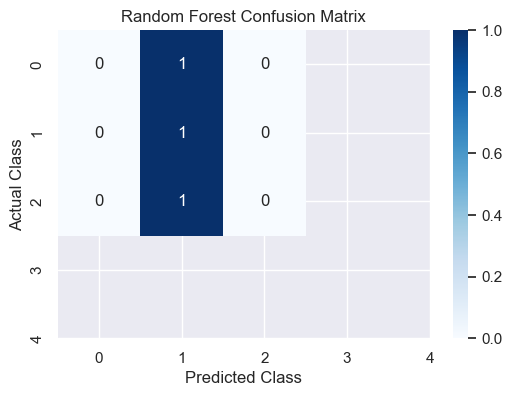

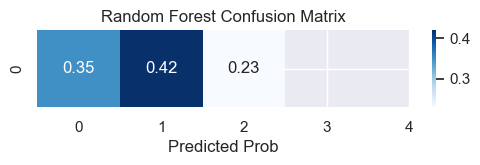

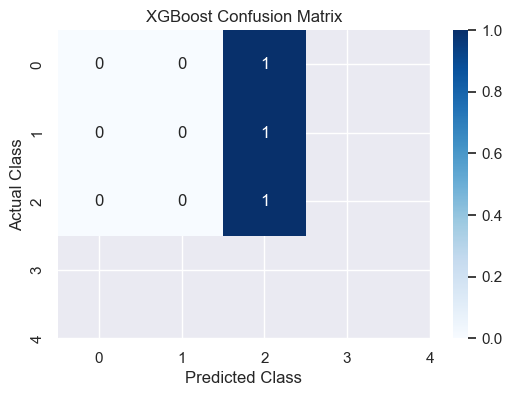

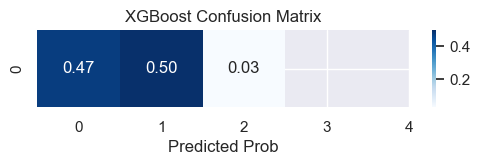

In [54]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Home

In [55]:
target = "GAC"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [56]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

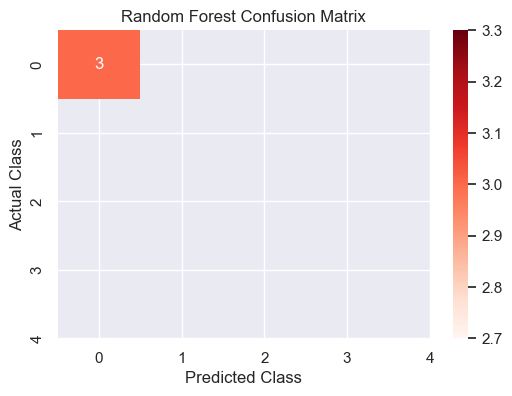

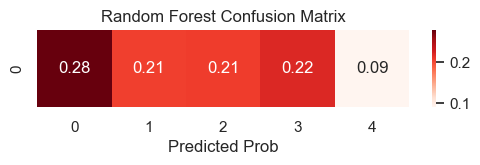

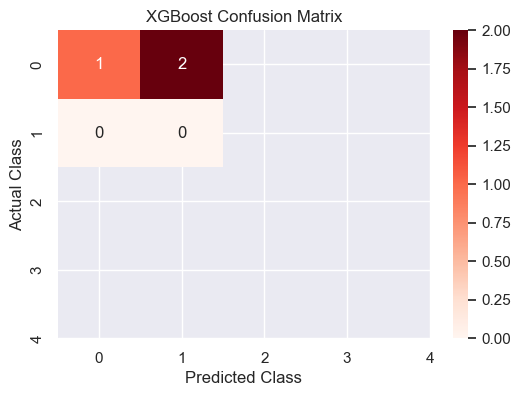

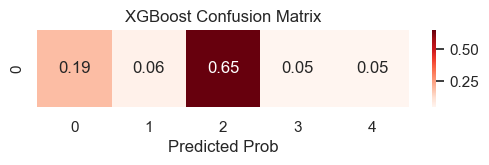

In [58]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_home_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model Away

In [59]:
target = "GFC"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [60]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [61]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

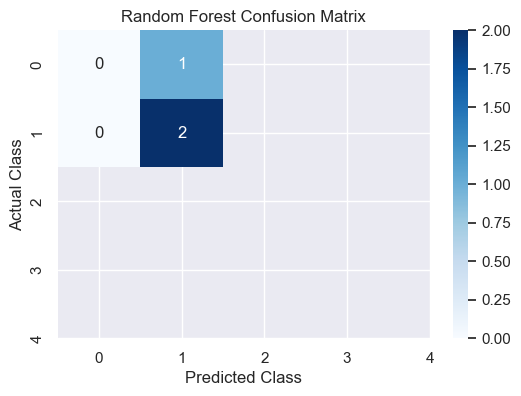

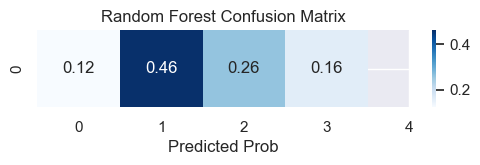

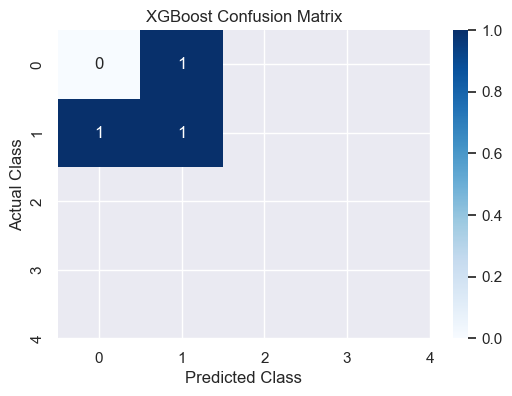

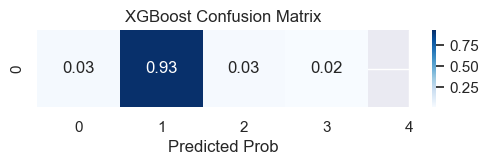

In [62]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_frw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

### Model vs Away

In [63]:
target = "GAC"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [64]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [65]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced', random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, objective='multi:softmax', 
                             num_class=6, eval_metric='mlogloss', random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

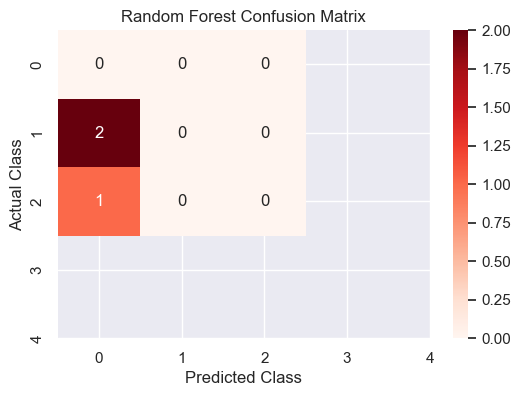

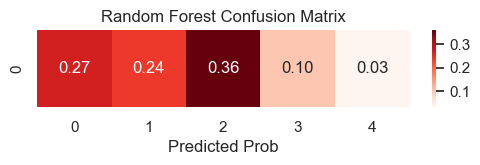

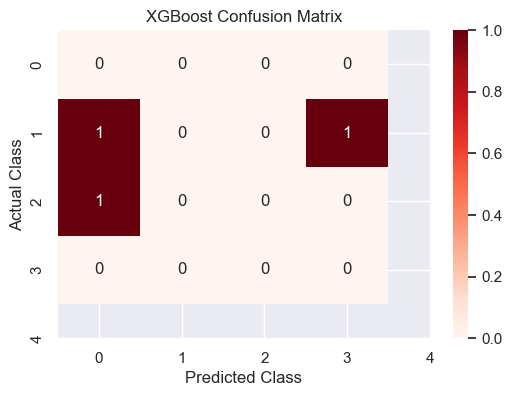

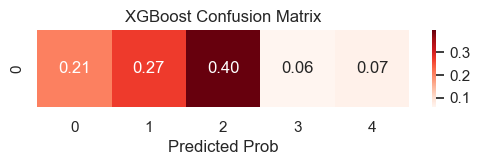

In [66]:
train_size = int(len(X) * 0.9)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
#results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    pred= model_pipeline.predict_proba(df_away_bcw)

    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    plt.figure(figsize=(6,1))
    sns.heatmap(pred, annot=True, fmt='.2f', cmap='Reds', xticklabels=labels)
    plt.xlabel("Predicted Prob")
    plt.ylabel("")
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    # Evaluate performance
    

## Regression

### Model Home

In [67]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_home_gf.drop(columns=[target])
y = df_home_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [68]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [69]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

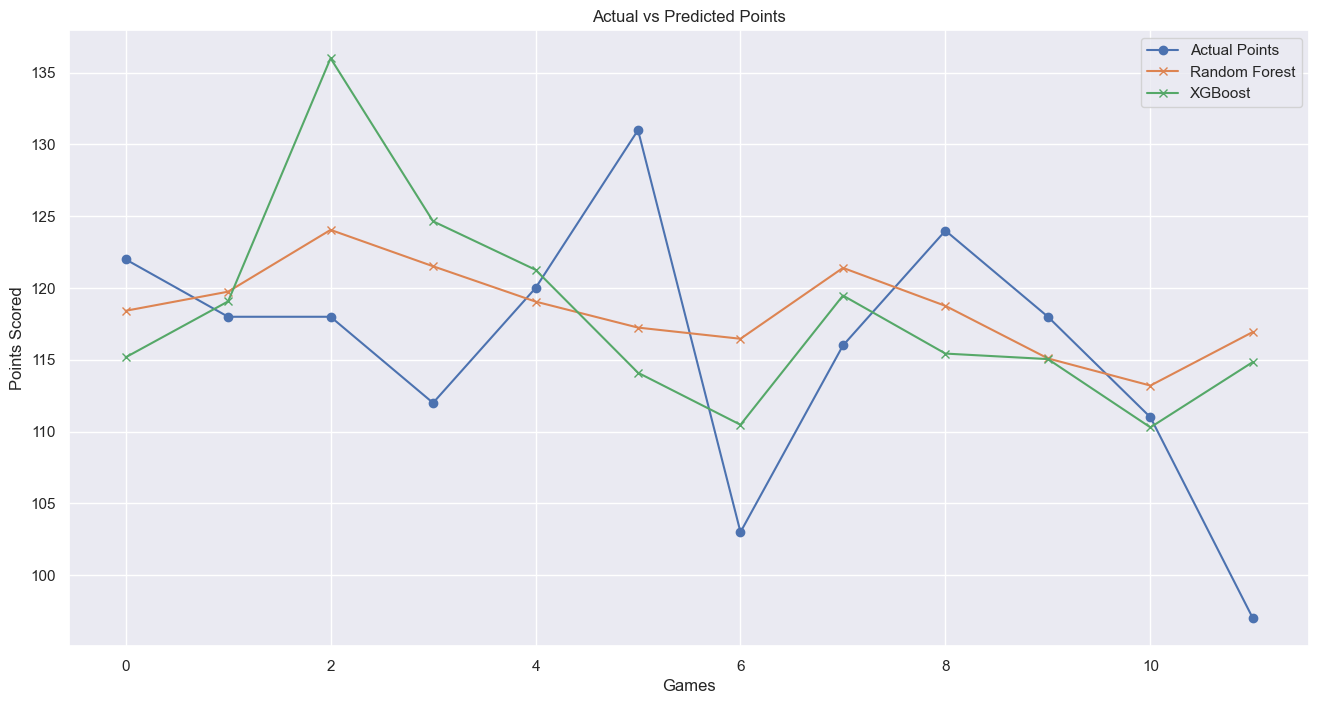

In [85]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
   # "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
   # "Linear Regression": LinearRegression()
}

# Split into training and testing sets
train_size = int(len(X) * 0.8)

X_train, y_train = X.iloc[:train_size], y.iloc[:train_size]
X_test, y_test = X.iloc[train_size:], y.iloc[train_size:]
# Train and evaluate each model
results = {}
plt.figure(figsize=(16,8))
plt.plot(y_test.values, label='Actual Points', marker='o')
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    plt.plot(y_pred, label=name, marker='x')
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred[0]}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T
plt.legend()
plt.title("Actual vs Predicted Points")
plt.xlabel("Games")
plt.ylabel("Points Scored")
plt.show()

In [80]:
results_df

,MAE,RMSE,PRED
Random Forest,7.063876,9.047376,117.443289
XGBoost,8.145854,10.362132,118.500099


### Model vs Home

In [48]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_home_ga.drop(columns=[target])
y = df_home_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [49]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [50]:
model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 13.425
RMSE: 14.329


In [52]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_home_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6818
[LightGBM] [Info] Number of data points in the train set: 52, number of used features: 405
[LightGBM] [Info] Start training from score 108.211538
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [53]:
results_df

,MAE,RMSE,PRED
Random Forest,13.041667,13.840622,[108.75]
XGBoost,13.151134,15.03493,[113.32865]
LightGBM,16.852781,18.445559,[102.71760442340414]
Linear Regression,24.528301,25.202121,[84.73789959470245]


### Model Away

In [54]:
target = "Tm_PTS"  # Goals For

# Separate features and target
X = df_away_gf.drop(columns=[target])
y = df_away_gf[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [55]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [57]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 12.708
RMSE: 14.490


In [59]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_frw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6654
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 121.941176
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [60]:
results_df

,MAE,RMSE,PRED
Random Forest,14.915,16.475376,[120.74]
XGBoost,12.521159,13.834184,[121.489395]
LightGBM,13.837515,17.031631,[126.221659266553]
Linear Regression,14.006226,16.370987,[137.60611314295068]


### Model vs Away

In [61]:
target = "Opp_PTS"  # Goals For

# Separate features and target
X = df_away_ga.drop(columns=[target])
y = df_away_ga[target]
categorical_features = ["H/A"]  # Home/Away column
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()


In [62]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

In [63]:
model_pipeline2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=20, random_state=25))
])

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train the model
model_pipeline2.fit(X_train, y_train)

# Predictions
y_pred = model_pipeline2.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: {mae:.3f}")
print(f"RMSE: {rmse:.3f}")


MAE: 10.350
RMSE: 11.309


In [65]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=25)

# Train and evaluate each model
results = {}
for name, model in models.items():
    # Define the pipeline
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    # Train the model
    model_pipeline.fit(X_train, y_train)
    
    # Predictions
    y_pred = model_pipeline.predict(X_test)
    
    # Evaluate performance
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    pred= model_pipeline.predict(df_away_bcw)
    
    results[name] = {"MAE": mae, "RMSE": rmse, "PRED": pred}

# Convert results to a DataFrame and display
results_df = pd.DataFrame(results).T

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000408 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6692
[LightGBM] [Info] Number of data points in the train set: 51, number of used features: 405
[LightGBM] [Info] Start training from score 110.666667
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [66]:
results_df

,MAE,RMSE,PRED
Random Forest,11.596667,12.906048,[108.99]
XGBoost,15.120514,16.820382,[102.5551]
LightGBM,9.838286,11.897321,[109.56588285586935]
Linear Regression,14.973625,19.146221,[86.82162740707135]
